# Task 5: Personal Loan Acceptance Prediction

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load Dataset & Basic Exploration

In [3]:
# Load the dataset
df = pd.read_csv('bank-full.csv', sep=';')   # Note: separator ';' hai is file mein

In [4]:
print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

Dataset Shape: (45211, 17)

Columns: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


In [5]:
print("\n=== First 5 Rows ===")
print(df.head())


=== First 5 Rows ===
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  


In [6]:
print("\n=== Data Types ===")
print(df.dtypes)


=== Data Types ===
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object


In [7]:
print("\n=== Missing Values ===")
print(df.isnull().sum())


=== Missing Values ===
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [8]:
print("\n=== Target Variable (y) Distribution ===")
print(df['y'].value_counts())
print("\nPercentage:")
print(df['y'].value_counts(normalize=True) * 100)


=== Target Variable (y) Distribution ===
y
no     39922
yes     5289
Name: count, dtype: int64

Percentage:
y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64


# Exploratory Data Analysis (EDA) + Key Visualizations

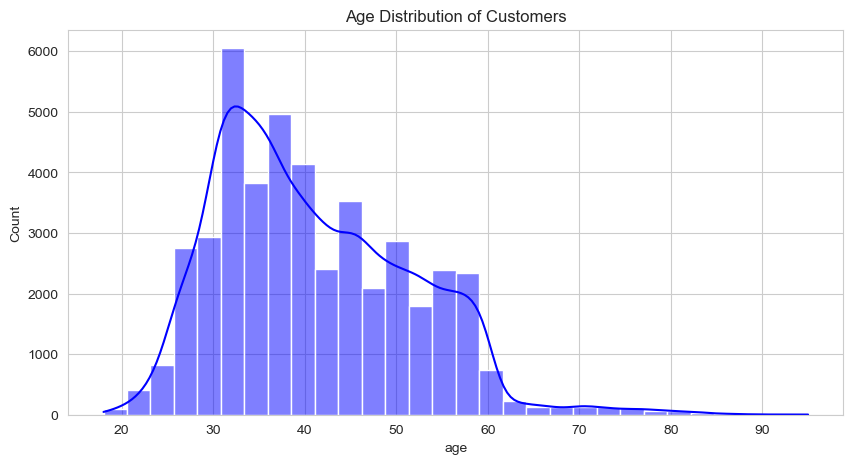

In [9]:
# 1. Age Distribution
plt.figure(figsize=(10,5))
sns.histplot(df['age'], bins=30, kde=True, color='blue')
plt.title('Age Distribution of Customers')
plt.show()

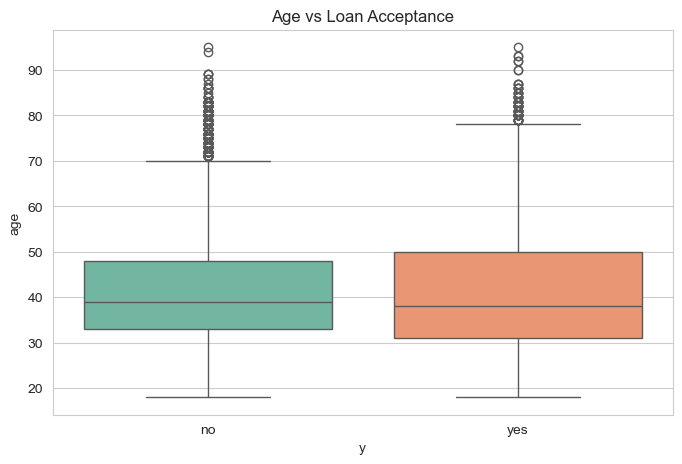

In [10]:
# 2. Target by Age (Box Plot)
plt.figure(figsize=(8,5))
sns.boxplot(x='y', y='age', data=df, palette='Set2')
plt.title('Age vs Loan Acceptance')
plt.show()

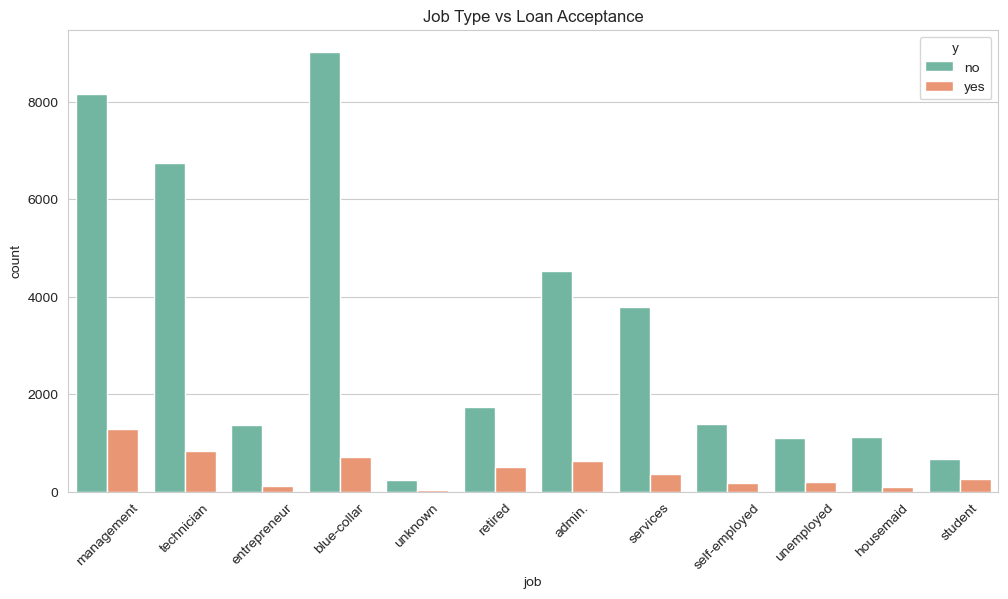

In [11]:
# 3. Job vs Loan Acceptance
plt.figure(figsize=(12,6))
sns.countplot(x='job', hue='y', data=df, palette='Set2')
plt.xticks(rotation=45)
plt.title('Job Type vs Loan Acceptance')
plt.show()

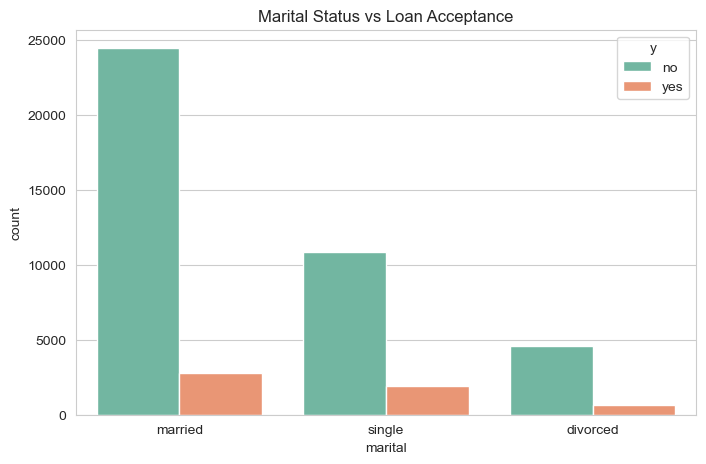

In [12]:
# 4. Marital Status vs Loan Acceptance
plt.figure(figsize=(8,5))
sns.countplot(x='marital', hue='y', data=df, palette='Set2')
plt.title('Marital Status vs Loan Acceptance')
plt.show()

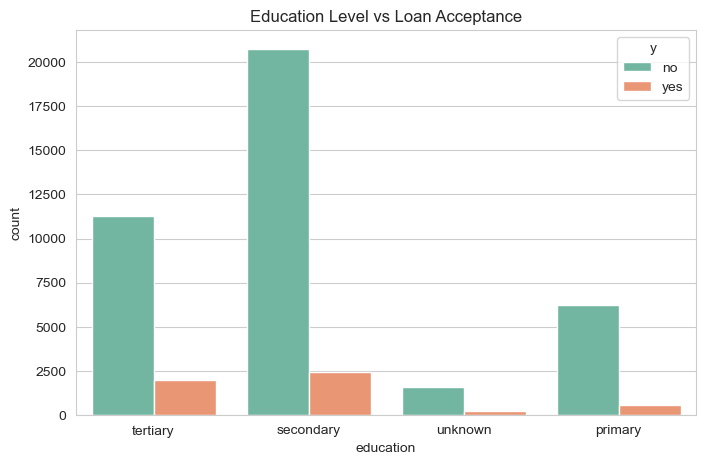

In [13]:
# 5. Education vs Loan Acceptance
plt.figure(figsize=(8,5))
sns.countplot(x='education', hue='y', data=df, palette='Set2')
plt.title('Education Level vs Loan Acceptance')
plt.show()

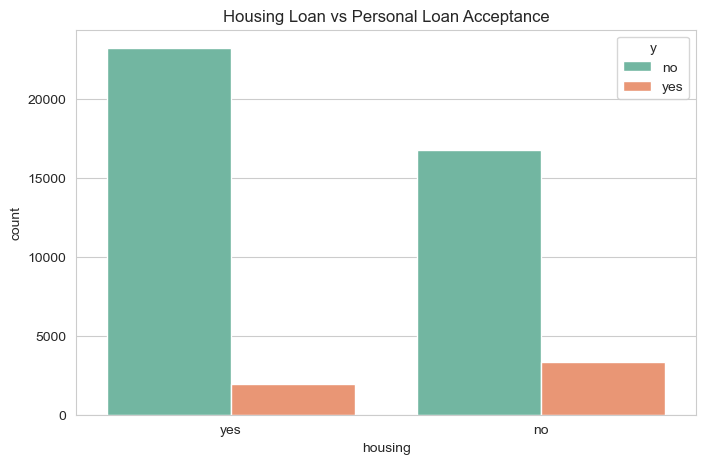

In [14]:
# 6. Housing Loan vs Target
plt.figure(figsize=(8,5))
sns.countplot(x='housing', hue='y', data=df, palette='Set2')
plt.title('Housing Loan vs Personal Loan Acceptance')
plt.show()

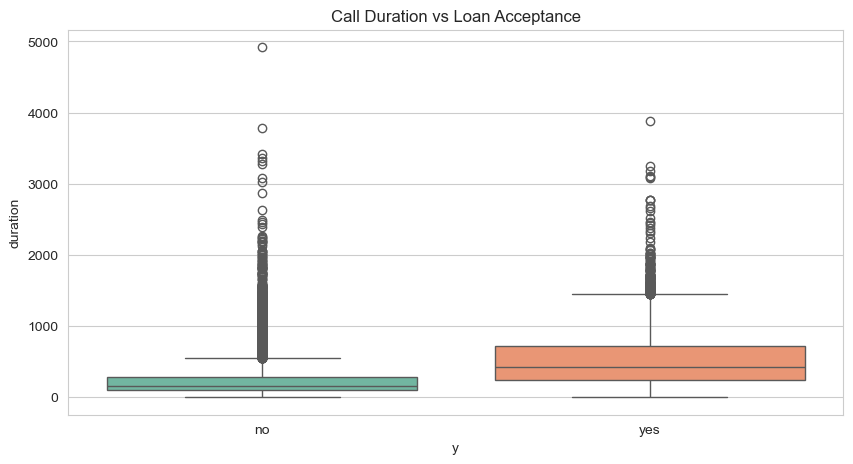

In [15]:
# 7. Duration (Call Duration) - Very Important Feature
plt.figure(figsize=(10,5))
sns.boxplot(x='y', y='duration', data=df, palette='Set2')
plt.title('Call Duration vs Loan Acceptance')
plt.show()


# Feature Encoding

In [16]:
df_model = df.copy()

In [17]:
# Label Encoding for binary categorical columns
le = LabelEncoder()
binary_cols = ['default', 'housing', 'loan', 'y']
for col in binary_cols:
    df_model[col] = le.fit_transform(df_model[col])

# One-Hot Encoding for multi-category columns
df_model = pd.get_dummies(df_model, columns=['job', 'marital', 'education', 'contact', 'month', 'poutcome'], 
                          drop_first=True)

print("Shape after Encoding:", df_model.shape)
print("Columns after encoding:", df_model.columns.tolist())


Shape after Encoding: (45211, 43)
Columns after encoding: ['age', 'default', 'balance', 'housing', 'loan', 'day', 'duration', 'campaign', 'pdays', 'previous', 'y', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'job_unknown', 'marital_married', 'marital_single', 'education_secondary', 'education_tertiary', 'education_unknown', 'contact_telephone', 'contact_unknown', 'month_aug', 'month_dec', 'month_feb', 'month_jan', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'poutcome_other', 'poutcome_success', 'poutcome_unknown']


 # Train-Test Split & Model Training

In [18]:
# Separate Features and Target
X = df_model.drop('y', axis=1)
y = df_model['y']

In [19]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

# 1. Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)


Training Shape: (36168, 42)
Testing Shape: (9043, 42)


In [20]:
# 2. Decision Tree
dt_model = DecisionTreeClassifier(max_depth=8, random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

# Model Evaluation

In [21]:
print("\n=== Logistic Regression Results ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred_log), 4))
print(classification_report(y_test, y_pred_log))

print("\n=== Decision Tree Results ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred_dt), 4))
print(classification_report(y_test, y_pred_dt))


=== Logistic Regression Results ===
Accuracy: 0.9004
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      7985
           1       0.64      0.34      0.44      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.66      0.70      9043
weighted avg       0.89      0.90      0.89      9043


=== Decision Tree Results ===
Accuracy: 0.8988
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      7985
           1       0.61      0.37      0.46      1058

    accuracy                           0.90      9043
   macro avg       0.77      0.67      0.70      9043
weighted avg       0.88      0.90      0.89      9043



# Feature Importance (Decision Tree)

In [22]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("=== Top 10 Most Important Features ===")
print(feature_importance.head(10))


=== Top 10 Most Important Features ===
             Feature  Importance
6           duration    0.466400
40  poutcome_success    0.234787
0                age    0.057688
8              pdays    0.053616
3            housing    0.044926
34         month_mar    0.034581
5                day    0.020705
2            balance    0.020148
27   contact_unknown    0.012277
37         month_oct    0.008512


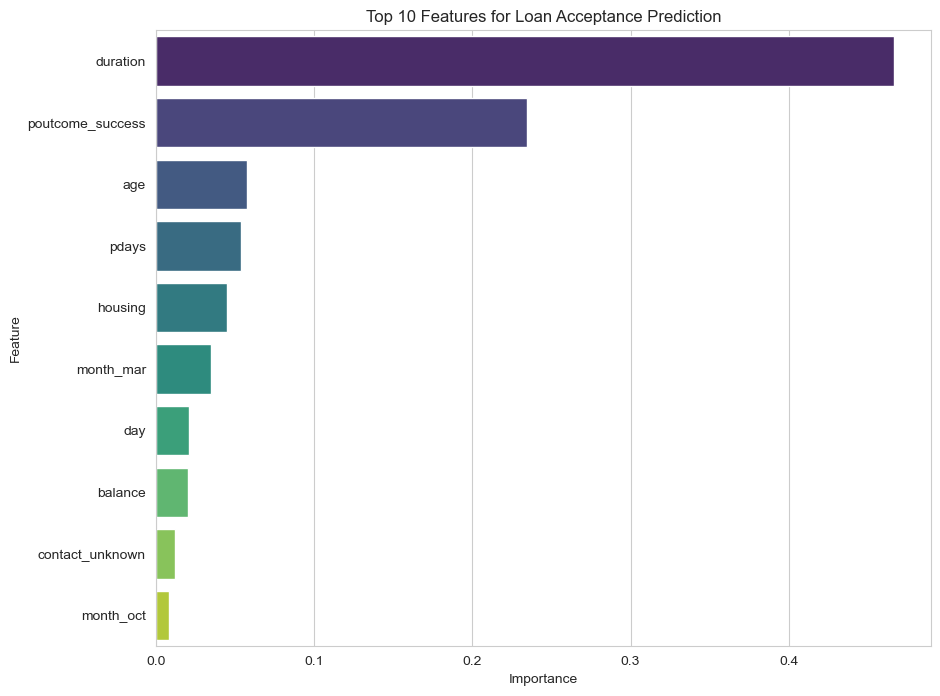

In [23]:
# Plot Feature Importance
plt.figure(figsize=(10,8))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10), palette='viridis')
plt.title('Top 10 Features for Loan Acceptance Prediction')
plt.show()

# Conclusion & Business Insights

# Conclusion & Business Insights

## Task Summary
Successfully developed a **Personal Loan Acceptance Prediction** model using the Bank Marketing Dataset (45,211 records). The objective was to identify customers who are likely to accept a personal loan offer.

## Model Performance
- **Logistic Regression**: Accuracy = **0.9004** (90.04%)
- **Decision Tree**: Accuracy = **0.8988** (89.88%)

Both models performed well considering the class imbalance (only 11.7% 'Yes').

## Key Findings from EDA & Feature Importance
- **Call Duration** is by far the most important feature — longer calls strongly indicate higher chance of loan acceptance.
- **Previous Campaign Outcome (poutcome_success)** plays a major role.
- Customers in **management, student, retired** jobs and those with **tertiary education** are more likely to accept.
- **Housing loan** customers are less likely to take another loan.
- Age, marital status (single), and balance also show meaningful impact.

## Business Recommendations
1. **Focus on Call Strategy**: Train tele-callers to have longer, more engaging conversations.
2. **Target Customer Segments**:
   - Students and Retired people
   - Management and self-employed professionals
   - Customers who had successful previous campaigns
3. **Avoid Wasting Resources** on customers who already have a housing loan or short call duration.
4. **Campaign Optimization**: Use model predictions to prioritize high-potential leads.

## Skills Demonstrated
- Data Exploration & Visualization
- Handling Categorical Features (Label + One-Hot Encoding)
- Classification Modeling (Logistic Regression & Decision Tree)
- Model Evaluation & Feature Importance Analysis
- Business Insight Generation

**This notebook fully satisfies all requirements of Task 5 as per DevelopersHub Internship guidelines.**